In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import joblib as jb

In [2]:
from sklearn.datasets import fetch_openml
x,y = fetch_openml("mnist_784",version=1,return_X_y=True,as_frame=False)

In [3]:
from sklearn.preprocessing import StandardScaler
x_test,x_train,y_test,y_train = x[60000:],x[:60000],y[60000:],y[:60000]
    

In [4]:
x_train.shape
y_train.shape

(60000,)

In [5]:
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.model_selection import  cross_val_score
# knclf = KNeighborsClassifier()
# score = cross_val_score(knclf,x_train,y_train,cv=3,scoring="accuracy")
# score.mean()


In [6]:
# from sklearn.model_selection import GridSearchCV
# knclfgsv = GridSearchCV(knclf,[{'n_neighbors':[3,4],'weights':['distance',"uniform"]}],scoring='accuracy',cv=3,return_train_score=True,verbose=3)
# knclfgsv.fit(x_train,y_train)

In [7]:
# knclfgsv.best_estimator_

In [8]:
# knclfgsv.best_score_

In [9]:
# training an ai modal to shift left,right , up and down 

In [10]:
somedigit = x[1]
somedigit_label = y[1]

In [11]:
def showimage(images: np.ndarray, figsize=(15, 5)):
    """
    Displays a list of images in a single horizontal row.
    
    Parameters:
    images (list or array): A list of image matrices (e.g., from MNIST).
    figsize (tuple): The overall size of the horizontal figure.
    """
    num_images = len(images)
    
    # squeeze=False ensures 'axes' is always a 2D array, even if there's only 1 image
    fig, axes = plt.subplots(nrows=1, ncols=num_images, figsize=figsize, squeeze=False)
    
    # Loop through the axes and the images simultaneously
    for i in range(0,num_images):
        # Display the image on this specific subplot
        img = images[i]
        img = img.reshape((28,28))
        axes[0,i].imshow(img, cmap='gray') 
        # Turn off the axis ticks/numbers for a clean look
        axes[0,i].axis('off')
        
    # Adjust spacing to prevent overlap
    plt.tight_layout()
    plt.show()

In [12]:
def shiftarray(arr: np.ndarray,shift: str):
    arr = arr.reshape((28,28))
    if(shift == "r" ):
        arr = np.roll(arr,shift=1,axis=1)
        print("right")
        return arr
    elif(shift == "l"):
        arr = np.roll(arr,shift=-1,axis=1)
        print("left")
        return arr
    elif(shift == "t"):
        arr = np.roll(arr,shift=-1,axis=0)
        print("top")
        return arr
    elif(shift == "b"):
        arr = np.roll(arr,shift=1,axis=0)
        print("bottom")
        return arr
    else: return arr

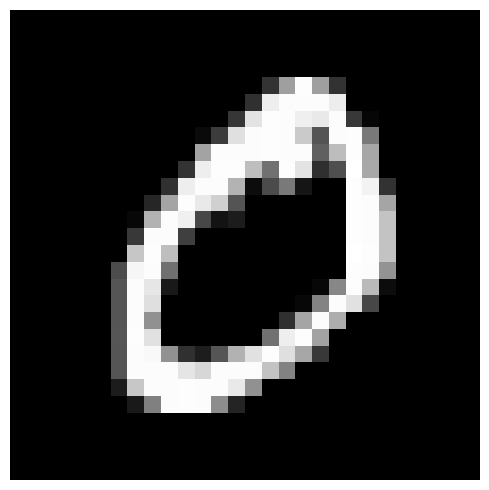

In [13]:
showimage([somedigit])

right
left
top
bottom


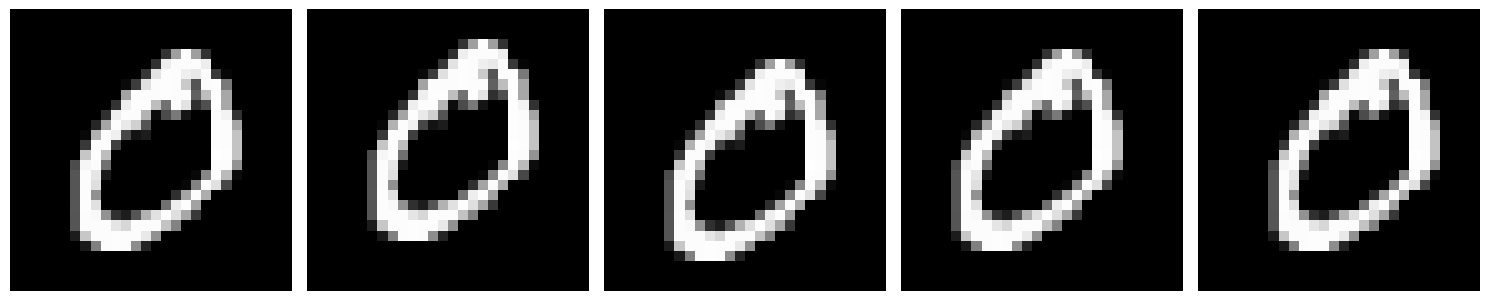

In [14]:
somedigitright = shiftarray(arr=somedigit,shift="r")
somedigitleft = shiftarray(arr=somedigit,shift="l")
somedigittop = shiftarray(arr=somedigit,shift="t")
somedigitbottom = shiftarray(arr=somedigit,shift="b")
showimage([somedigit,somedigittop,somedigitbottom,somedigitleft,somedigitright])

In [15]:
# 1. Get the number of training instances
N = x_train.shape[0]

# 2. Pre-allocate a single target array of shape (N * 5, 28, 28)
# This holds the original + 4 shifted copies in 2D format
x_train_augmented = np.zeros((N * 5, 28, 28), dtype=x_train.dtype)

# 3. Copy the original images into the first block (0 to N-1)
x_train_augmented[:N] = x_train.reshape(-1, 28, 28)

# 4. Perform vectorized shifting in-place using slicing
# Shift Left: shift column values from index 1: to : -1
x_train_augmented[N : 2*N, :, :-1] = x_train_augmented[:N, :, 1:]

# Shift Right: shift column values from index :-1 to 1:
x_train_augmented[2*N : 3*N, :, 1:] = x_train_augmented[:N, :, :-1]

# Shift Up (Top): shift row values from index 1: to :-1
x_train_augmented[3*N : 4*N, :-1, :] = x_train_augmented[:N, 1:, :]

# Shift Down (Bottom): shift row values from index :-1 to 1:
x_train_augmented[4*N :, 1:, :]     = x_train_augmented[:N, :-1, :]

# 5. Flatten the augmented images back to 1D vectors (300000, 784)
x_train_augmented = x_train_augmented.reshape(-1, 784)

# 6. Replicate the labels 5 times to match the shifted image blocks
y_train_augmented = np.tile(y_train, 5)

# 7. Update the original train variables
x_train = x_train_augmented
y_train = y_train_augmented


In [16]:
x_train.shape

(300000, 784)

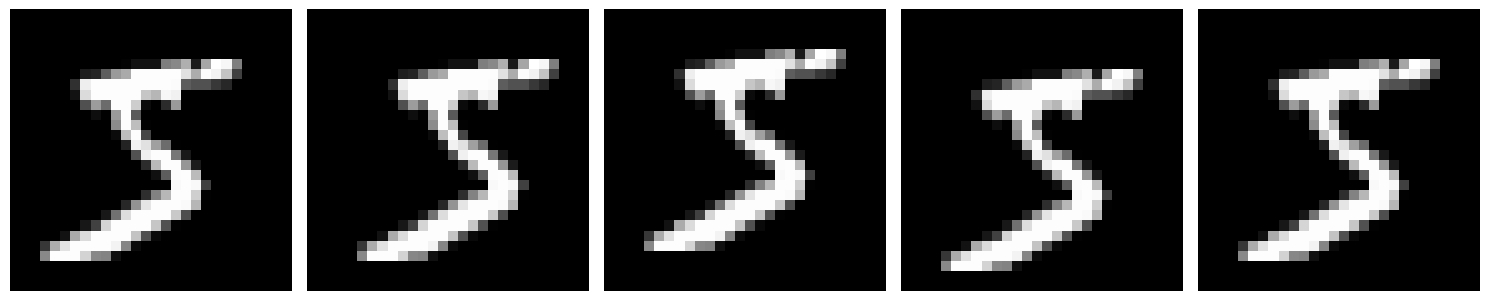

In [ ]:
# showimage([x_train[N],x_train[N*2],x_train[N*3],x_train[N*4],x_train[0]])

In [ ]:
# from sklearn.model_selection import cross_val_score
# from sklearn.neighbors import KNeighborsClassifier
# knclf = KNeighborsClassifier()
# score = cross_val_score(knclf,x_train,y_train,cv=2,scoring="accuracy")